
Rows loaded: 17701
Rows with usable zipcode: 17693
Rows with usable closed time: 17315
Rows with bad close date: 0

Slowest ZIP codes by median days to close:
zipcode  request_count  avg_days_to_close  median_days_to_close  min_days_to_close  max_days_to_close  total_rows  closed_rows  open_rows  avg_time_open_days  median_time_open_days  pct_closed
  75246             37              15.41                  4.91               0.11             105.13          37           37          0               15.41                   4.91       100.0
  75205             33              12.16                  4.66               0.01              63.92          33           33          0               12.16                   4.66       100.0
  75201            956               6.73                  4.00               0.01             131.11         968          956         12                7.32                   4.29        98.8
  75202            312               5.34                  3.92     

<Figure size 1400x700 with 0 Axes>

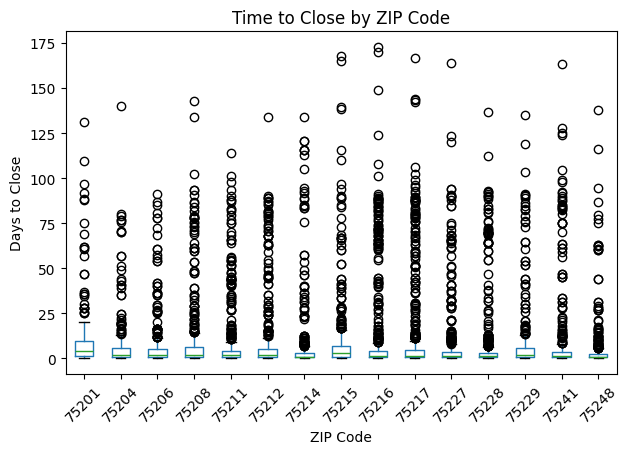


Saved plot to:
C:\2026_06_26_Hackathon\Data\zipcode_time_to_close_boxplot.png


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Set paths
base_path = Path(r"C:\2026_06_26_Hackathon")
csv_path = base_path / "Data" / "sara_lights_results_df.csv"
out_path = base_path / "Data" / "zipcode_time_to_close_patterns.csv"
plot_path = base_path / "Data" / "zipcode_time_to_close_boxplot.png"

df_service_light = pd.read_csv(csv_path)
df_service_light.columns = df_service_light.columns.str.strip().str.lower() # Clean column names

# Convert dates
for col in ["created_date", "update_date", "closed_date"]:
    df_service_light[col] = pd.to_datetime(df_service_light[col], errors="coerce")

# Derive zipcode from address
df_service_light["zipcode"] = df_service_light["address"].astype(str).str.extract(r"(\d{5})(?:-\d{4})?\s*$")

# Derive time_to_close from created_date to closed_date
df_service_light["time_to_close"] = df_service_light["closed_date"] - df_service_light["created_date"]
df_service_light["time_to_close_days"] = df_service_light["time_to_close"].dt.total_seconds() / 86400

# Derive time_open: use closed_date if available, else update_date, else today
today = pd.Timestamp.today()
df_service_light["open_end_date"] = df_service_light["closed_date"].fillna(df_service_light["update_date"]).fillna(today)
df_service_light["time_open"] = df_service_light["open_end_date"] - df_service_light["created_date"]
df_service_light["time_open_days"] = df_service_light["time_open"].dt.total_seconds() / 86400

# Flag questionable date rows
df_service_light["bad_close_date"] = df_service_light["closed_date"].notna() & df_service_light["created_date"].notna() & (df_service_light["closed_date"] < df_service_light["created_date"])
df_service_light["bad_open_date"] = df_service_light["created_date"].notna() & (df_service_light["open_end_date"] < df_service_light["created_date"])

# Keep usable rows for close-time analysis
df_closed_service_light = df_service_light[df_service_light["time_to_close_days"].notna() & df_service_light["zipcode"].notna() & ~df_service_light["bad_close_date"]].copy()

# Summarize close-time patterns by zipcode
zipcode_summary = df_closed_service_light.groupby("zipcode").agg(
    request_count=("time_to_close_days", "size"),
    avg_days_to_close=("time_to_close_days", "mean"),
    median_days_to_close=("time_to_close_days", "median"),
    min_days_to_close=("time_to_close_days", "min"),
    max_days_to_close=("time_to_close_days", "max")
).reset_index()

zipcode_summary["avg_days_to_close"] = zipcode_summary["avg_days_to_close"].round(2)
zipcode_summary["median_days_to_close"] = zipcode_summary["median_days_to_close"].round(2)
zipcode_summary["min_days_to_close"] = zipcode_summary["min_days_to_close"].round(2)
zipcode_summary["max_days_to_close"] = zipcode_summary["max_days_to_close"].round(2)

# Add closed/open status pattern by zipcode
status_summary = df_service_light.groupby("zipcode").agg(
    total_rows=("zipcode", "size"),
    closed_rows=("closed_date", lambda s: s.notna().sum()),
    open_rows=("closed_date", lambda s: s.isna().sum()),
    avg_time_open_days=("time_open_days", "mean"),
    median_time_open_days=("time_open_days", "median")
).reset_index()

status_summary["pct_closed"] = (status_summary["closed_rows"] / status_summary["total_rows"] * 100).round(1)
status_summary["avg_time_open_days"] = status_summary["avg_time_open_days"].round(2)
status_summary["median_time_open_days"] = status_summary["median_time_open_days"].round(2)

# Combine summaries
zipcode_patterns = zipcode_summary.merge(status_summary, on="zipcode", how="outer")
zipcode_patterns = zipcode_patterns.sort_values(["median_days_to_close", "request_count"], ascending=[False, False])

# Save results
zipcode_patterns.to_csv(out_path, index=False)

# Print important patterns
print("\nRows loaded:", len(df_service_light))
print("Rows with usable zipcode:", df_service_light["zipcode"].notna().sum())
print("Rows with usable closed time:", len(df_closed_service_light))
print("Rows with bad close date:", df_service_light["bad_close_date"].sum())

print("\nSlowest ZIP codes by median days to close:")
print(zipcode_patterns[zipcode_patterns["request_count"] >= 5].head(15).to_string(index=False))

print("\nFastest ZIP codes by median days to close:")
print(zipcode_patterns[zipcode_patterns["request_count"] >= 5].sort_values("median_days_to_close").head(15).to_string(index=False))

print("\nSaved summary to:")
print(out_path)

# Make boxplot for top ZIP codes by request volume
top_zips = df_closed_service_light["zipcode"].value_counts().head(15).index
plot_df = df_closed_service_light[df_closed_service_light["zipcode"].isin(top_zips)].copy()

plt.figure(figsize=(14, 7))
plot_df.boxplot(column="time_to_close_days", by="zipcode", grid=False, rot=45)
plt.title("Time to Close by ZIP Code")
plt.suptitle("")
plt.xlabel("ZIP Code")
plt.ylabel("Days to Close")
plt.tight_layout()
plt.savefig(plot_path, dpi=200)
plt.show()

print("\nSaved plot to:")
print(plot_path)

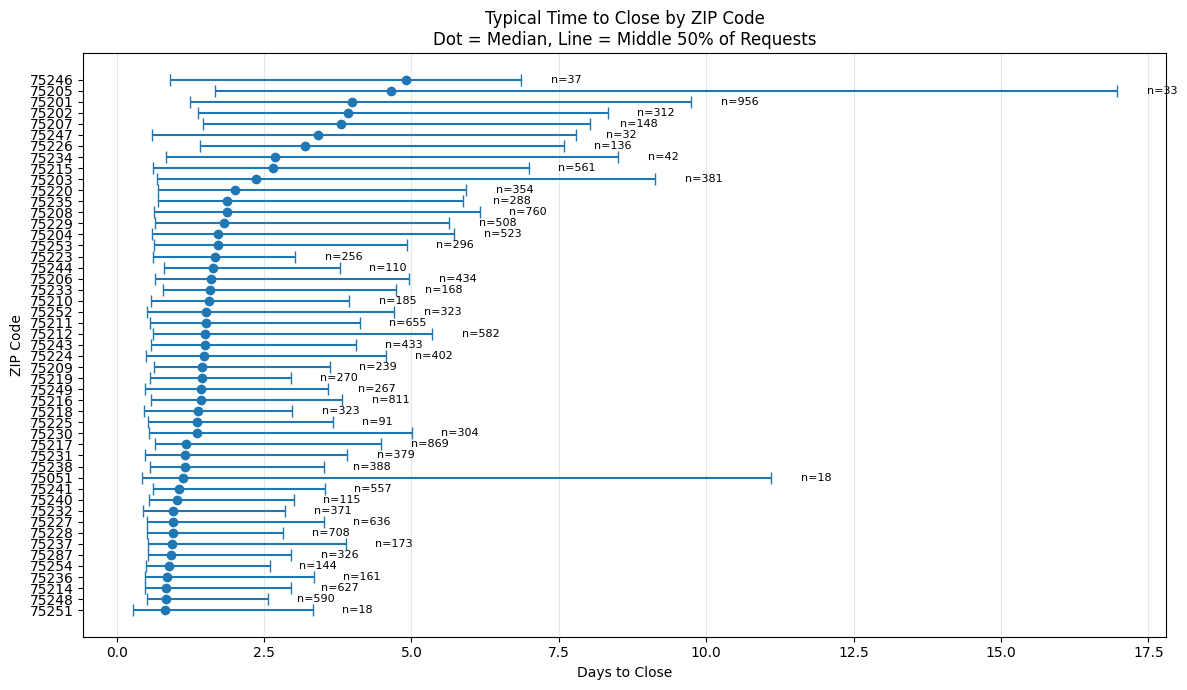

In [7]:

# Plot median close time by ZIP code with middle 50% range.
plot_df = df_closed_service_light[["zipcode", "time_to_close_days"]].dropna().copy()
plot_df["zipcode"] = plot_df["zipcode"].astype(str)

zip_summary = plot_df.groupby("zipcode")["time_to_close_days"].agg(
    n="count",
    median="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).reset_index()

zip_summary = zip_summary[zip_summary["n"] >= 10].sort_values("median")
zip_summary["lower_error"] = zip_summary["median"] - zip_summary["q1"]
zip_summary["upper_error"] = zip_summary["q3"] - zip_summary["median"]

plt.figure(figsize=(12, 7))
plt.errorbar(
    zip_summary["median"],
    zip_summary["zipcode"],
    xerr=[zip_summary["lower_error"], zip_summary["upper_error"]],
    fmt="o",
    capsize=4
)

plt.xlabel("Days to Close")
plt.ylabel("ZIP Code")
plt.title("Typical Time to Close by ZIP Code\nDot = Median, Line = Middle 50% of Requests")
plt.grid(axis="x", alpha=0.3)

for _, row in zip_summary.iterrows():
    plt.text(row["q3"] + 0.5, row["zipcode"], f"n={int(row['n'])}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\tracy\AppData\Local\Temp\ipykernel_29656\2785644695.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, vert=False, labels=zip_order, showfliers=True)


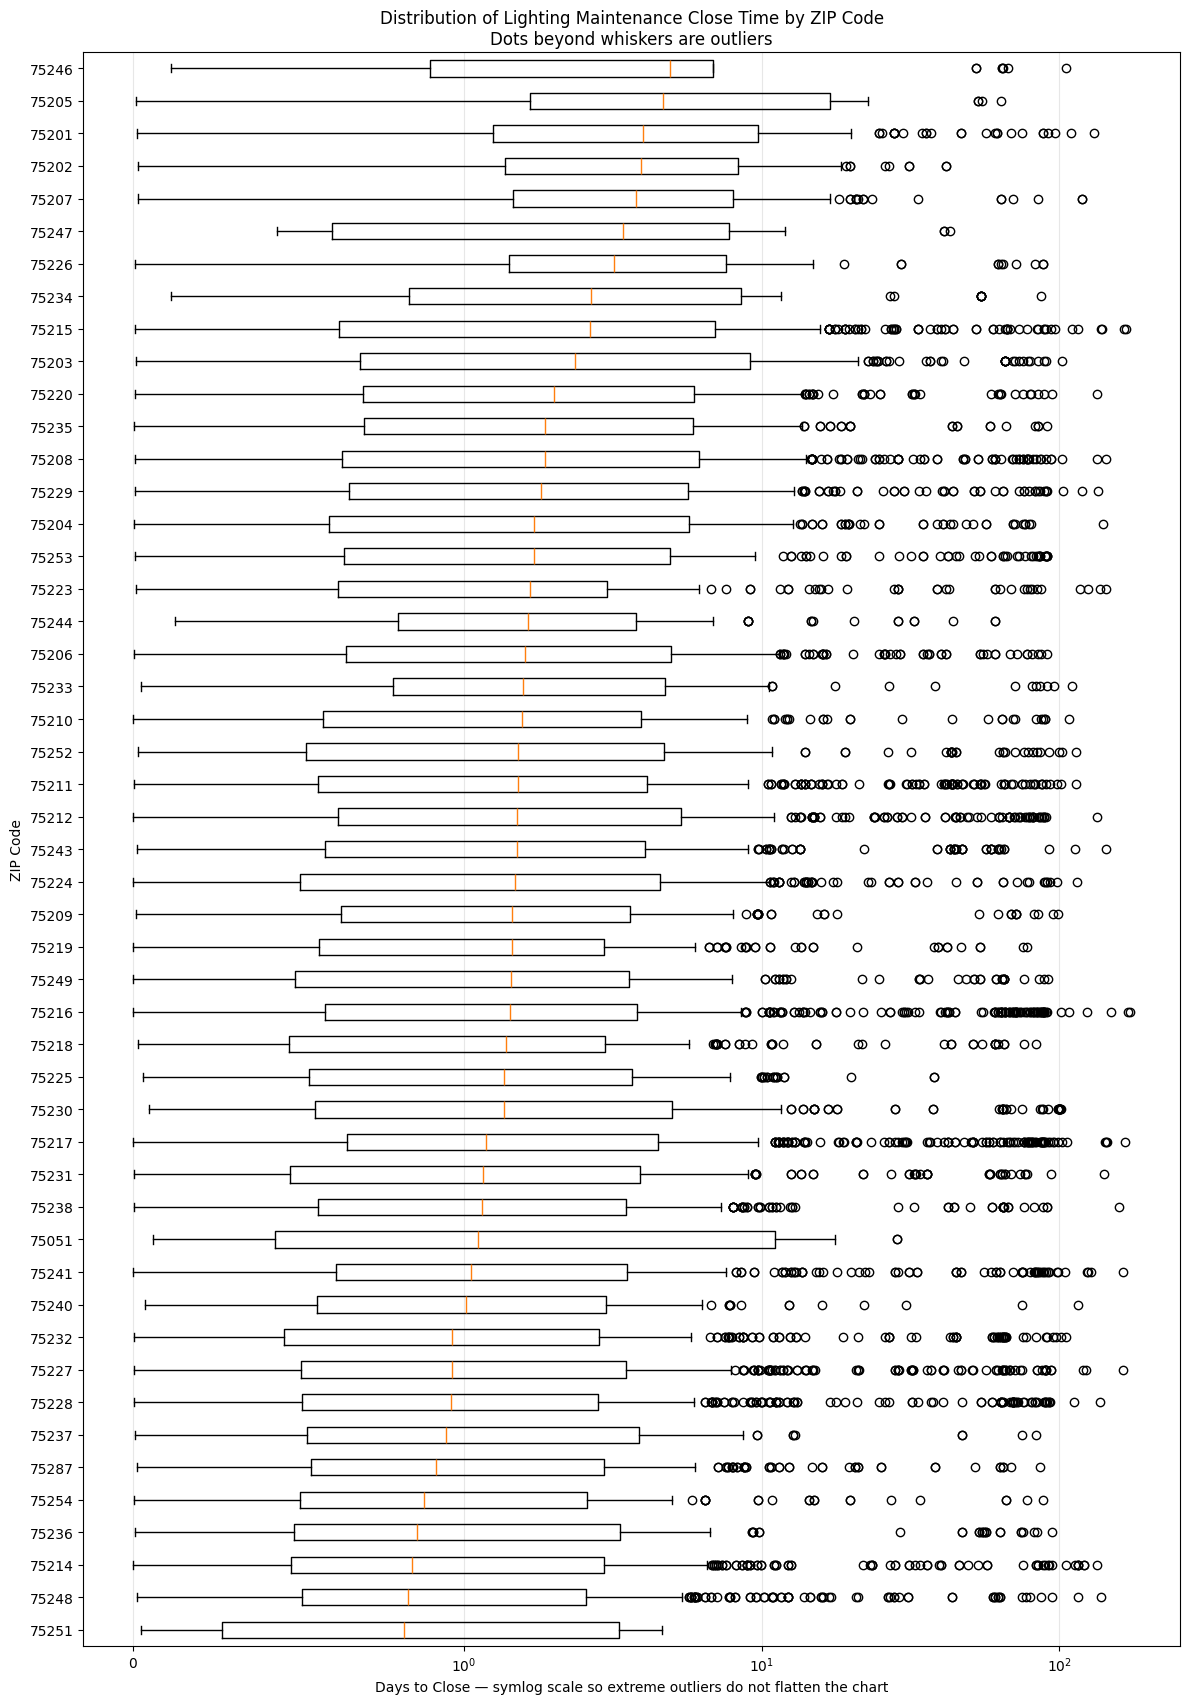

In [12]:
# Plot close-time distribution by ZIP code to detect outliers.
import pandas as pd
import matplotlib.pyplot as plt

min_requests = 10

plot_df = df_closed_service_light[["zipcode", "time_to_close_days"]].copy()
plot_df["zipcode"] = plot_df["zipcode"].astype(str).str.replace(".0", "", regex=False)
plot_df["time_to_close_days"] = pd.to_numeric(plot_df["time_to_close_days"], errors="coerce")
plot_df = plot_df.dropna()
plot_df = plot_df[plot_df["time_to_close_days"] >= 0]

zip_counts = plot_df["zipcode"].value_counts()
plot_df = plot_df[plot_df["zipcode"].isin(zip_counts[zip_counts >= min_requests].index)]

zip_order = plot_df.groupby("zipcode")["time_to_close_days"].median().sort_values().index.tolist()
box_data = [plot_df.loc[plot_df["zipcode"] == z, "time_to_close_days"] for z in zip_order]

plt.figure(figsize=(12, max(6, len(zip_order) * 0.35)))
plt.boxplot(box_data, vert=False, labels=zip_order, showfliers=True)

plt.xscale("symlog", linthresh=1)
plt.xlabel("Days to Close — symlog scale so extreme outliers do not flatten the chart")
plt.ylabel("ZIP Code")
plt.title("Distribution of Lighting Maintenance Close Time by ZIP Code\nDots beyond whiskers are outliers")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

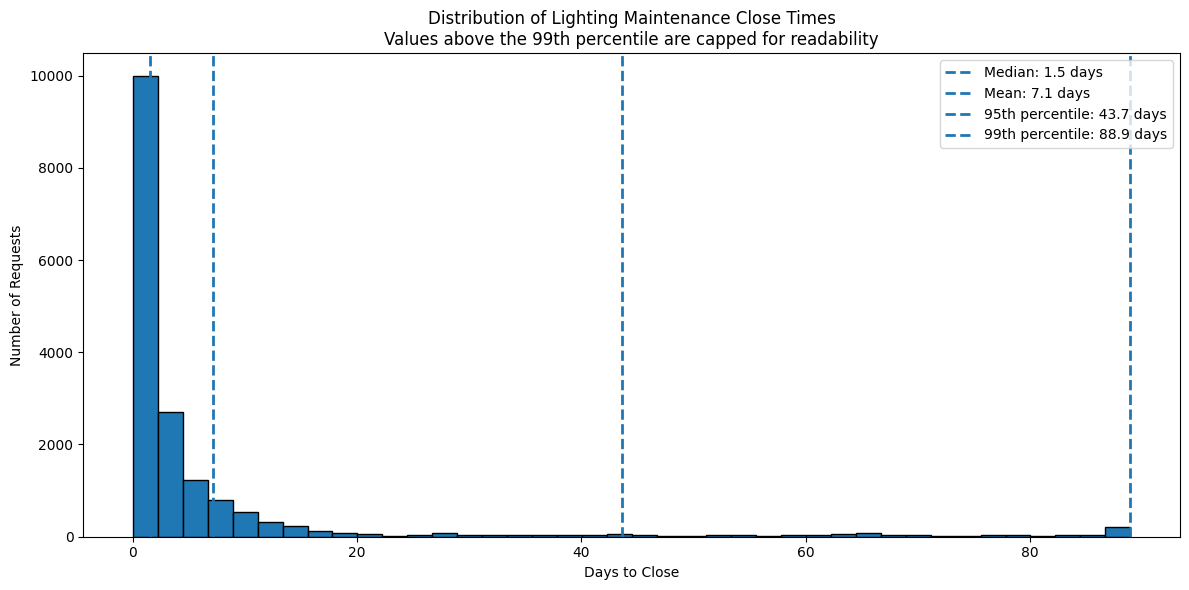

Total requests plotted: 17,315
Maximum close time: 172.8 days
Requests above 99th percentile: 174


In [13]:
# Plot distribution of lighting maintenance close times.
import pandas as pd
import matplotlib.pyplot as plt

days = pd.to_numeric(df_closed_service_light["time_to_close_days"], errors="coerce").dropna()
days = days[days >= 0]

median_days = days.median()
mean_days = days.mean()
p95 = days.quantile(0.95)
p99 = days.quantile(0.99)
max_days = days.max()

plt.figure(figsize=(12, 6))
plt.hist(days.clip(upper=p99), bins=40, edgecolor="black")
plt.axvline(median_days, linestyle="--", linewidth=2, label=f"Median: {median_days:.1f} days")
plt.axvline(mean_days, linestyle="--", linewidth=2, label=f"Mean: {mean_days:.1f} days")
plt.axvline(p95, linestyle="--", linewidth=2, label=f"95th percentile: {p95:.1f} days")
plt.axvline(p99, linestyle="--", linewidth=2, label=f"99th percentile: {p99:.1f} days")

plt.xlabel("Days to Close")
plt.ylabel("Number of Requests")
plt.title("Distribution of Lighting Maintenance Close Times\nValues above the 99th percentile are capped for readability")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total requests plotted: {len(days):,}")
print(f"Maximum close time: {max_days:.1f} days")
print(f"Requests above 99th percentile: {(days > p99).sum():,}")

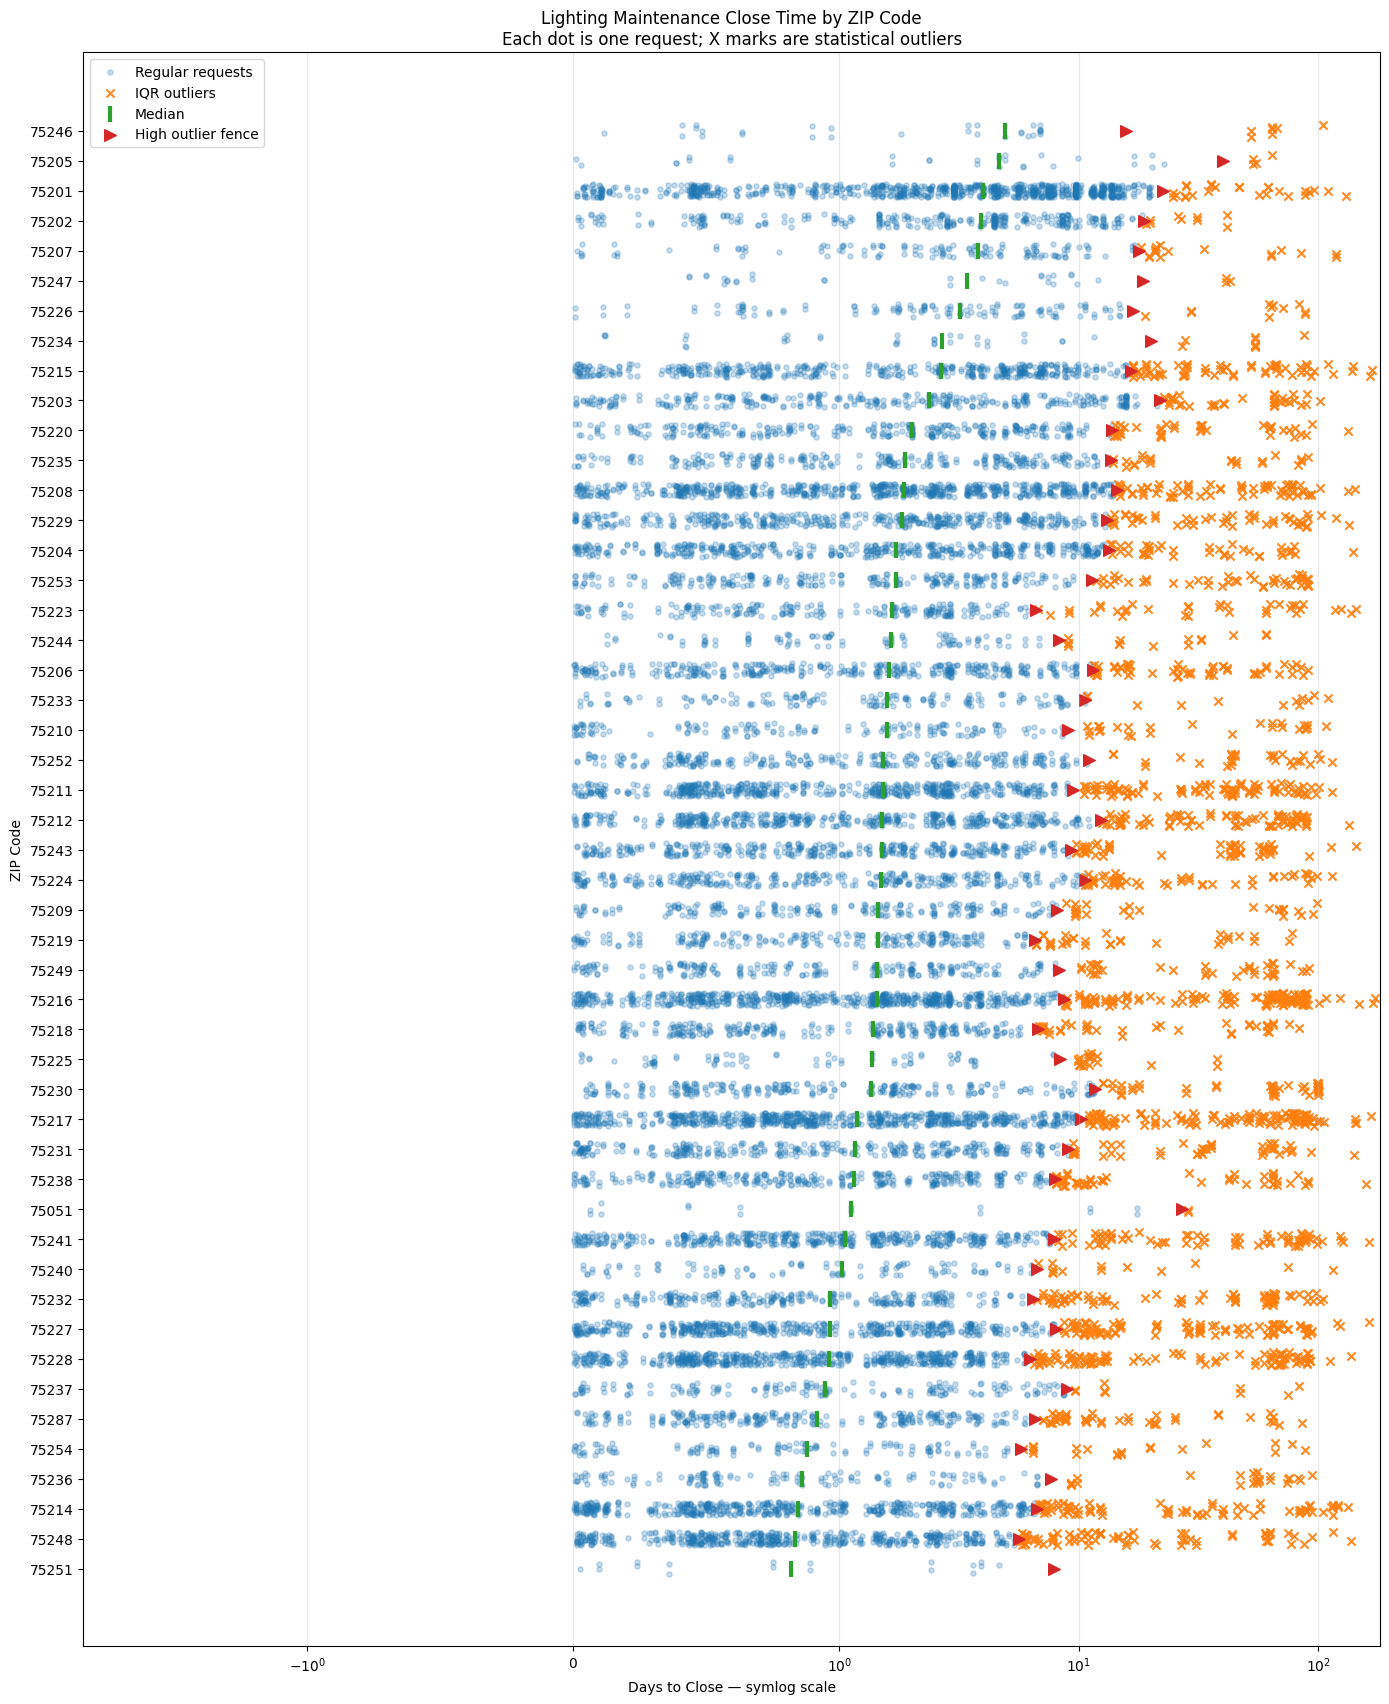

Flagged 2,028 outliers out of 17,300 requests across 49 ZIP codes.


In [14]:
# Plot every request by ZIP and flag IQR outliers.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

min_requests = 10

d = df_closed_service_light[["zipcode", "time_to_close_days"]].copy()
d["zipcode"] = d["zipcode"].astype(str).str.replace(".0", "", regex=False)
d["time_to_close_days"] = pd.to_numeric(d["time_to_close_days"], errors="coerce")
d = d.dropna()
d = d[d["time_to_close_days"] >= 0]

zip_counts = d["zipcode"].value_counts()
d = d[d["zipcode"].isin(zip_counts[zip_counts >= min_requests].index)].copy()

bounds = d.groupby("zipcode")["time_to_close_days"].agg(
    n="count",
    q1=lambda x: x.quantile(0.25),
    median="median",
    q3=lambda x: x.quantile(0.75)
).reset_index()

bounds["iqr"] = bounds["q3"] - bounds["q1"]
bounds["low_fence"] = bounds["q1"] - 1.5 * bounds["iqr"]
bounds["high_fence"] = bounds["q3"] + 1.5 * bounds["iqr"]

d = d.merge(bounds[["zipcode", "low_fence", "high_fence"]], on="zipcode", how="left")
d["is_outlier"] = (d["time_to_close_days"] < d["low_fence"]) | (d["time_to_close_days"] > d["high_fence"])

zip_order = bounds.sort_values("median")["zipcode"].tolist()
zip_y = {z: i for i, z in enumerate(zip_order)}
d["y"] = d["zipcode"].map(zip_y)

rng = np.random.default_rng(42)
d["y_jitter"] = d["y"] + rng.uniform(-0.22, 0.22, len(d))
bounds["y"] = bounds["zipcode"].map(zip_y)

regular = d[d["is_outlier"] == False]
outliers = d[d["is_outlier"] == True]

plt.figure(figsize=(14, max(7, len(zip_order) * 0.35)))
plt.scatter(regular["time_to_close_days"], regular["y_jitter"], s=14, alpha=0.25, label="Regular requests")
plt.scatter(outliers["time_to_close_days"], outliers["y_jitter"], s=35, marker="x", alpha=0.9, label="IQR outliers")
plt.scatter(bounds["median"], bounds["y"], s=140, marker="|", linewidths=3, label="Median")
plt.scatter(bounds["high_fence"], bounds["y"], s=70, marker=">", label="High outlier fence")

plt.yticks(range(len(zip_order)), zip_order)
plt.xscale("symlog", linthresh=1)
plt.xlabel("Days to Close — symlog scale")
plt.ylabel("ZIP Code")
plt.title("Lighting Maintenance Close Time by ZIP Code\nEach dot is one request; X marks are statistical outliers")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Flagged {len(outliers):,} outliers out of {len(d):,} requests across {len(zip_order)} ZIP codes.")